In [1]:
import random

class MultiversedWeather:
    def __init__(self, steps):
        self.actual_weather = []  # 現実の天気推移: [w0, w1, w2...]
        self.models = []          # モデルのリスト
        self.multiverse_log = []   # 全モデルの全日程の予測記録

    def run(self, days):
        for d in range(days):
            # 1. 現実の天気が確定（0〜100の気圧指数的なもの）
            today_actual = random.randint(0, 100)
            self.actual_weather.append(today_actual)

            # 2. 新しいモデルが誕生 (前日までの現実を知っている)
            # 生まれた日は NaN (予測なし) の代わりとして、翌日以降の計算に備える
            new_model = {"id": d, "drift": random.uniform(-5, 5)}
            self.models.append(new_model)

            # 3. 全モデルが「今日」の予測を出力
            daily_predictions = []
            for m in self.models:
                if m["id"] == d:
                    # 生まれたてのモデルは現実と一致している（観測）
                    pred = today_actual
                else:
                    # 過去のモデルは独自の「宇宙の癖（drift）」で現実から離れていく
                    # 昨日の自分の予測に、独自の変動を加える
                    prev_pred = self.multiverse_log[d-1][m["id"]]
                    pred = prev_pred + m["drift"] + random.uniform(-2, 2)

                daily_predictions.append(round(pred, 1))

            self.multiverse_log.append(daily_predictions)
            self.display_day(d)

    def display_day(self, d):
        print(f"--- Day {d} ---")
        print(f"Actual Weather: {self.actual_weather[d]}")
        for m_id, pred in enumerate(self.multiverse_log[d]):
            status = "Newborn" if m_id == d else "Diverged"
            print(f"  Model {m_id} [{status}]: {pred}")
        print()

# 実行
mv = MultiversedWeather(steps=5)
mv.run(5)


--- Day 0 ---
Actual Weather: 59
  Model 0 [Newborn]: 59

--- Day 1 ---
Actual Weather: 2
  Model 0 [Diverged]: 60.5
  Model 1 [Newborn]: 2

--- Day 2 ---
Actual Weather: 21
  Model 0 [Diverged]: 62.3
  Model 1 [Diverged]: 4.5
  Model 2 [Newborn]: 21

--- Day 3 ---
Actual Weather: 7
  Model 0 [Diverged]: 65.4
  Model 1 [Diverged]: 8.7
  Model 2 [Diverged]: 22.3
  Model 3 [Newborn]: 7

--- Day 4 ---
Actual Weather: 77
  Model 0 [Diverged]: 70.2
  Model 1 [Diverged]: 11.3
  Model 2 [Diverged]: 24.9
  Model 3 [Diverged]: 10.4
  Model 4 [Newborn]: 77



In [3]:
import pandas as pd
import numpy as np

# シミュレーション設定
days = 6
weather = [random.randint(990, 1030) for _ in range(days)] # 現実の気圧推移
data = {"Actual Weather": weather}

# 各モデルの宇宙を生成
for m_id in range(days):
    predictions = []
    drift = random.uniform(-10, 10) # モデル固有の「宇宙の癖」

    for d in range(days):
        if d <= m_id:
            # 誕生前、および誕生当日は予測値を持たない（NaN）
            predictions.append(np.nan)
        elif d == m_id + 1:
            # 誕生直後の予測は、前日の現実をベースにする
            predictions.append(weather[m_id] + drift)
        else:
            # それ以降は「自分の宇宙の過去値」をベースに進化（現実から離れる）
            prev_pred = predictions[d-1]
            predictions.append(prev_pred + drift + random.uniform(-2, 2))

    data[f"Model {m_id}"] = predictions

# 表（データフレーム）の作成
df = pd.DataFrame(data)
df.index.name = "Day"
print(df.round(1).fillna("-"))


     Actual Weather Model 0 Model 1 Model 2 Model 3 Model 4 Model 5
Day                                                                
0              1012       -       -       -       -       -       -
1              1008  1018.6       -       -       -       -       -
2              1023  1025.6  1016.8       -       -       -       -
3              1010  1030.6  1024.4  1017.1       -       -       -
4              1001  1039.2  1035.1  1011.8  1011.5       -       -
5              1030  1044.4  1043.8  1006.1  1011.3  1006.8       -


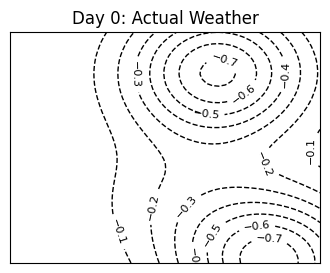

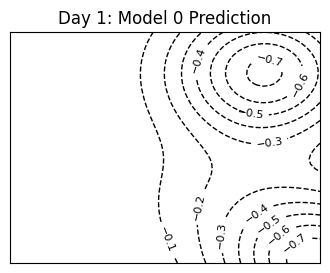

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def generate_weather_pattern(seed, drift=0):
    """
    シード値に基づいて気圧配置（等圧線データ）を生成する
    """
    np.random.seed(seed)
    grid = 50
    x = np.linspace(0, 10, grid)
    y = np.linspace(0, 10, grid)
    X, Y = np.meshgrid(x, y)

    # ランダムな高気圧・低気圧の核を3つ生成
    Z = np.zeros((grid, grid))
    for _ in range(3):
        center_x, center_y = np.random.uniform(0, 10, 2)
        # driftを加えることで、過去のモデルが現実からズレていく様子を再現
        center_x += drift
        strength = np.random.uniform(-1, 1)
        Z += strength * np.exp(-((X - center_x)**2 + (Y - center_y)**2) / 8)
    return X, Y, Z

def draw_map(X, Y, Z, title):
    plt.figure(figsize=(4, 3))
    # 等圧線の描画
    cp = plt.contour(X, Y, Z, colors='black', linewidths=1)
    plt.clabel(cp, inline=True, fontsize=8) # 気圧の数値ラベル
    plt.title(title)
    plt.xticks([]); plt.yticks([]) # 座標軸を消して地図っぽく
    plt.show()

# --- 0日目: 現実の天気が生まれる ---
actual_seed_day0 = 100
X, Y, Z_actual = generate_weather_pattern(actual_seed_day0)
draw_map(X, Y, Z_actual, "Day 0: Actual Weather")

# --- 1日目: モデル0が予測する「並行世界」の天気図 ---
# モデルはDay 0の現実を知っているが、計算のズレ(drift)で少し違う未来を描く
X, Y, Z_model0 = generate_weather_pattern(actual_seed_day0, drift=1.5)
draw_map(X, Y, Z_model0, "Day 1: Model 0 Prediction")


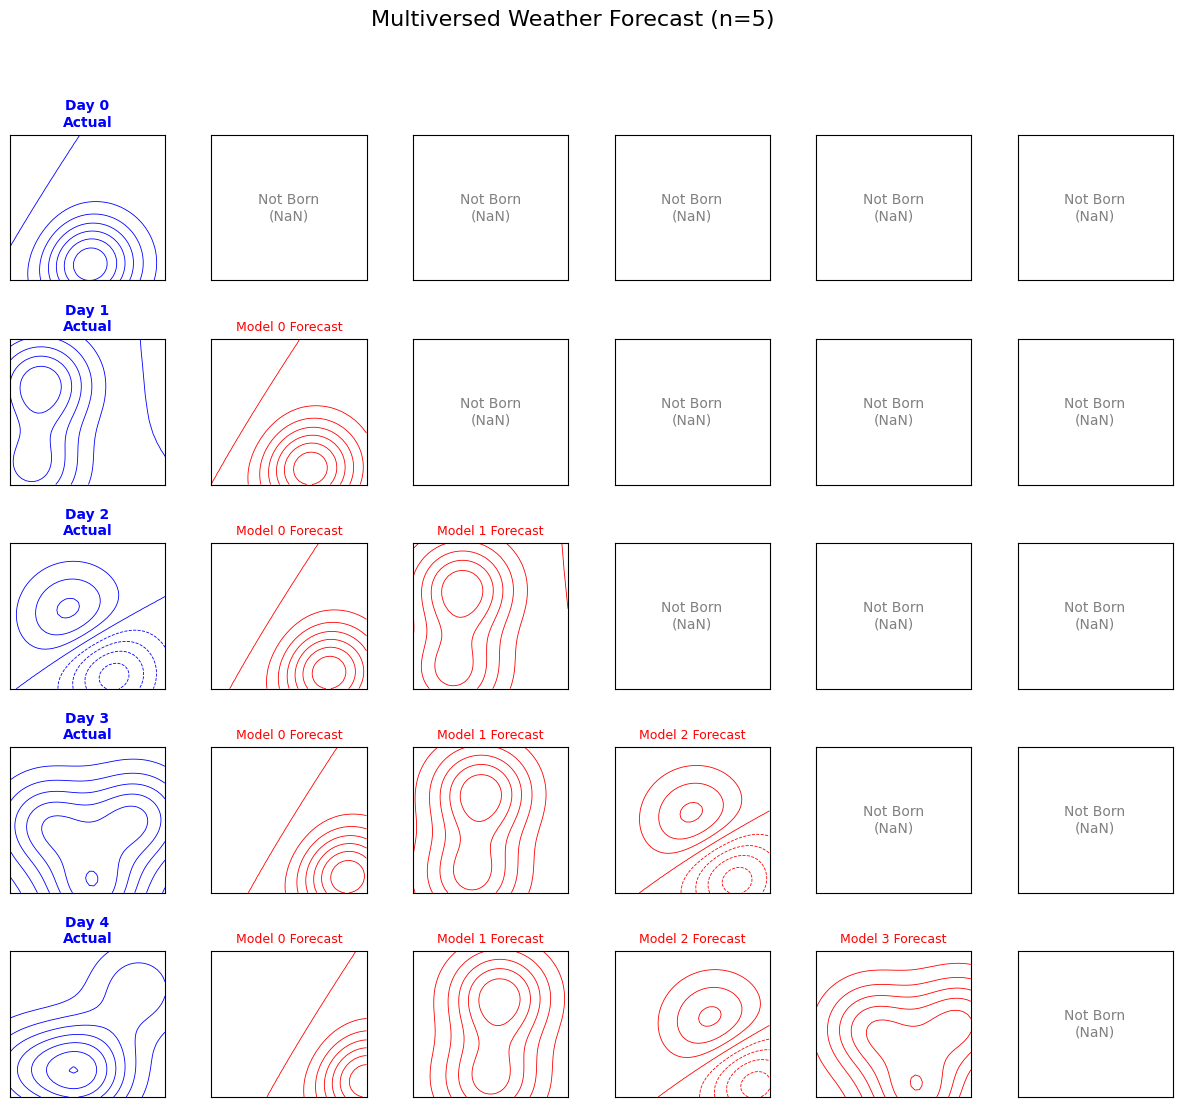

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def create_multiverse_weather_map(days=5):
    # 日本付近の気圧配置を模したグリッド
    grid_size = 40
    x = np.linspace(0, 10, grid_size)
    y = np.linspace(0, 10, grid_size)
    X, Y = np.meshgrid(x, y)

    # 各日の「現実」のシード値を固定
    actual_seeds = [np.random.randint(0, 1000) for _ in range(days)]

    # 描画設定（行：日付、列：現実 + 各モデル）
    fig, axes = plt.subplots(days, days + 1, figsize=((days+1)*2.5, days*2.5))
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    def generate_z(seed, drift=0):
        """シードとドリフト（ズレ）から気圧データを生成"""
        np.random.seed(seed)
        Z = np.zeros((grid_size, grid_size))
        for _ in range(3): # 3つの気圧中心
            cx, cy = np.random.uniform(0, 10, 2)
            strength = np.random.uniform(-1, 1)
            # driftによって低気圧・高気圧の位置が宇宙ごとにズレる
            Z += strength * np.exp(-((X - (cx + drift))**2 + (Y - cy)**2) / 10)
        return Z

    for d in range(days):
        # --- 列0: 現実の天気 (Actual Weather) ---
        Z_actual = generate_z(actual_seeds[d])
        ax_act = axes[d, 0]
        ax_act.contour(X, Y, Z_actual, colors='blue', linewidths=0.6)
        ax_act.set_title(f"Day {d}\nActual", fontsize=10, fontweight='bold', color='blue')

        # --- 列1〜n: 各モデルの予測宇宙 ---
        for m_id in range(days):
            ax = axes[d, m_id + 1]
            if d <= m_id:
                # 誕生前、または誕生当日はデータなし(NaN)
                ax.text(0.5, 0.5, "Not Born\n(NaN)", ha='center', va='center', color='gray')
            else:
                # 誕生日の現実をベースに、経過日数(d - m_id)に応じて「宇宙が分岐(drift)」
                drift_amount = (d - m_id) * 1.2
                Z_pred = generate_z(actual_seeds[m_id], drift=drift_amount)
                ax.contour(X, Y, Z_pred, colors='red', linewidths=0.6)
                ax.set_title(f"Model {m_id} Forecast", fontsize=9, color='red')

            # 共通の軸設定
            ax.set_xticks([]); ax.set_yticks([])

        # 行見出し的な処理（一番左の軸にだけDayを表示）
        axes[d, 0].set_xticks([]); axes[d, 0].set_yticks([])

    plt.suptitle(f"Multiversed Weather Forecast (n={days})", fontsize=16)
    plt.show()

# 変数nを自由に変えて実行
n = 5
create_multiverse_weather_map(days=n)


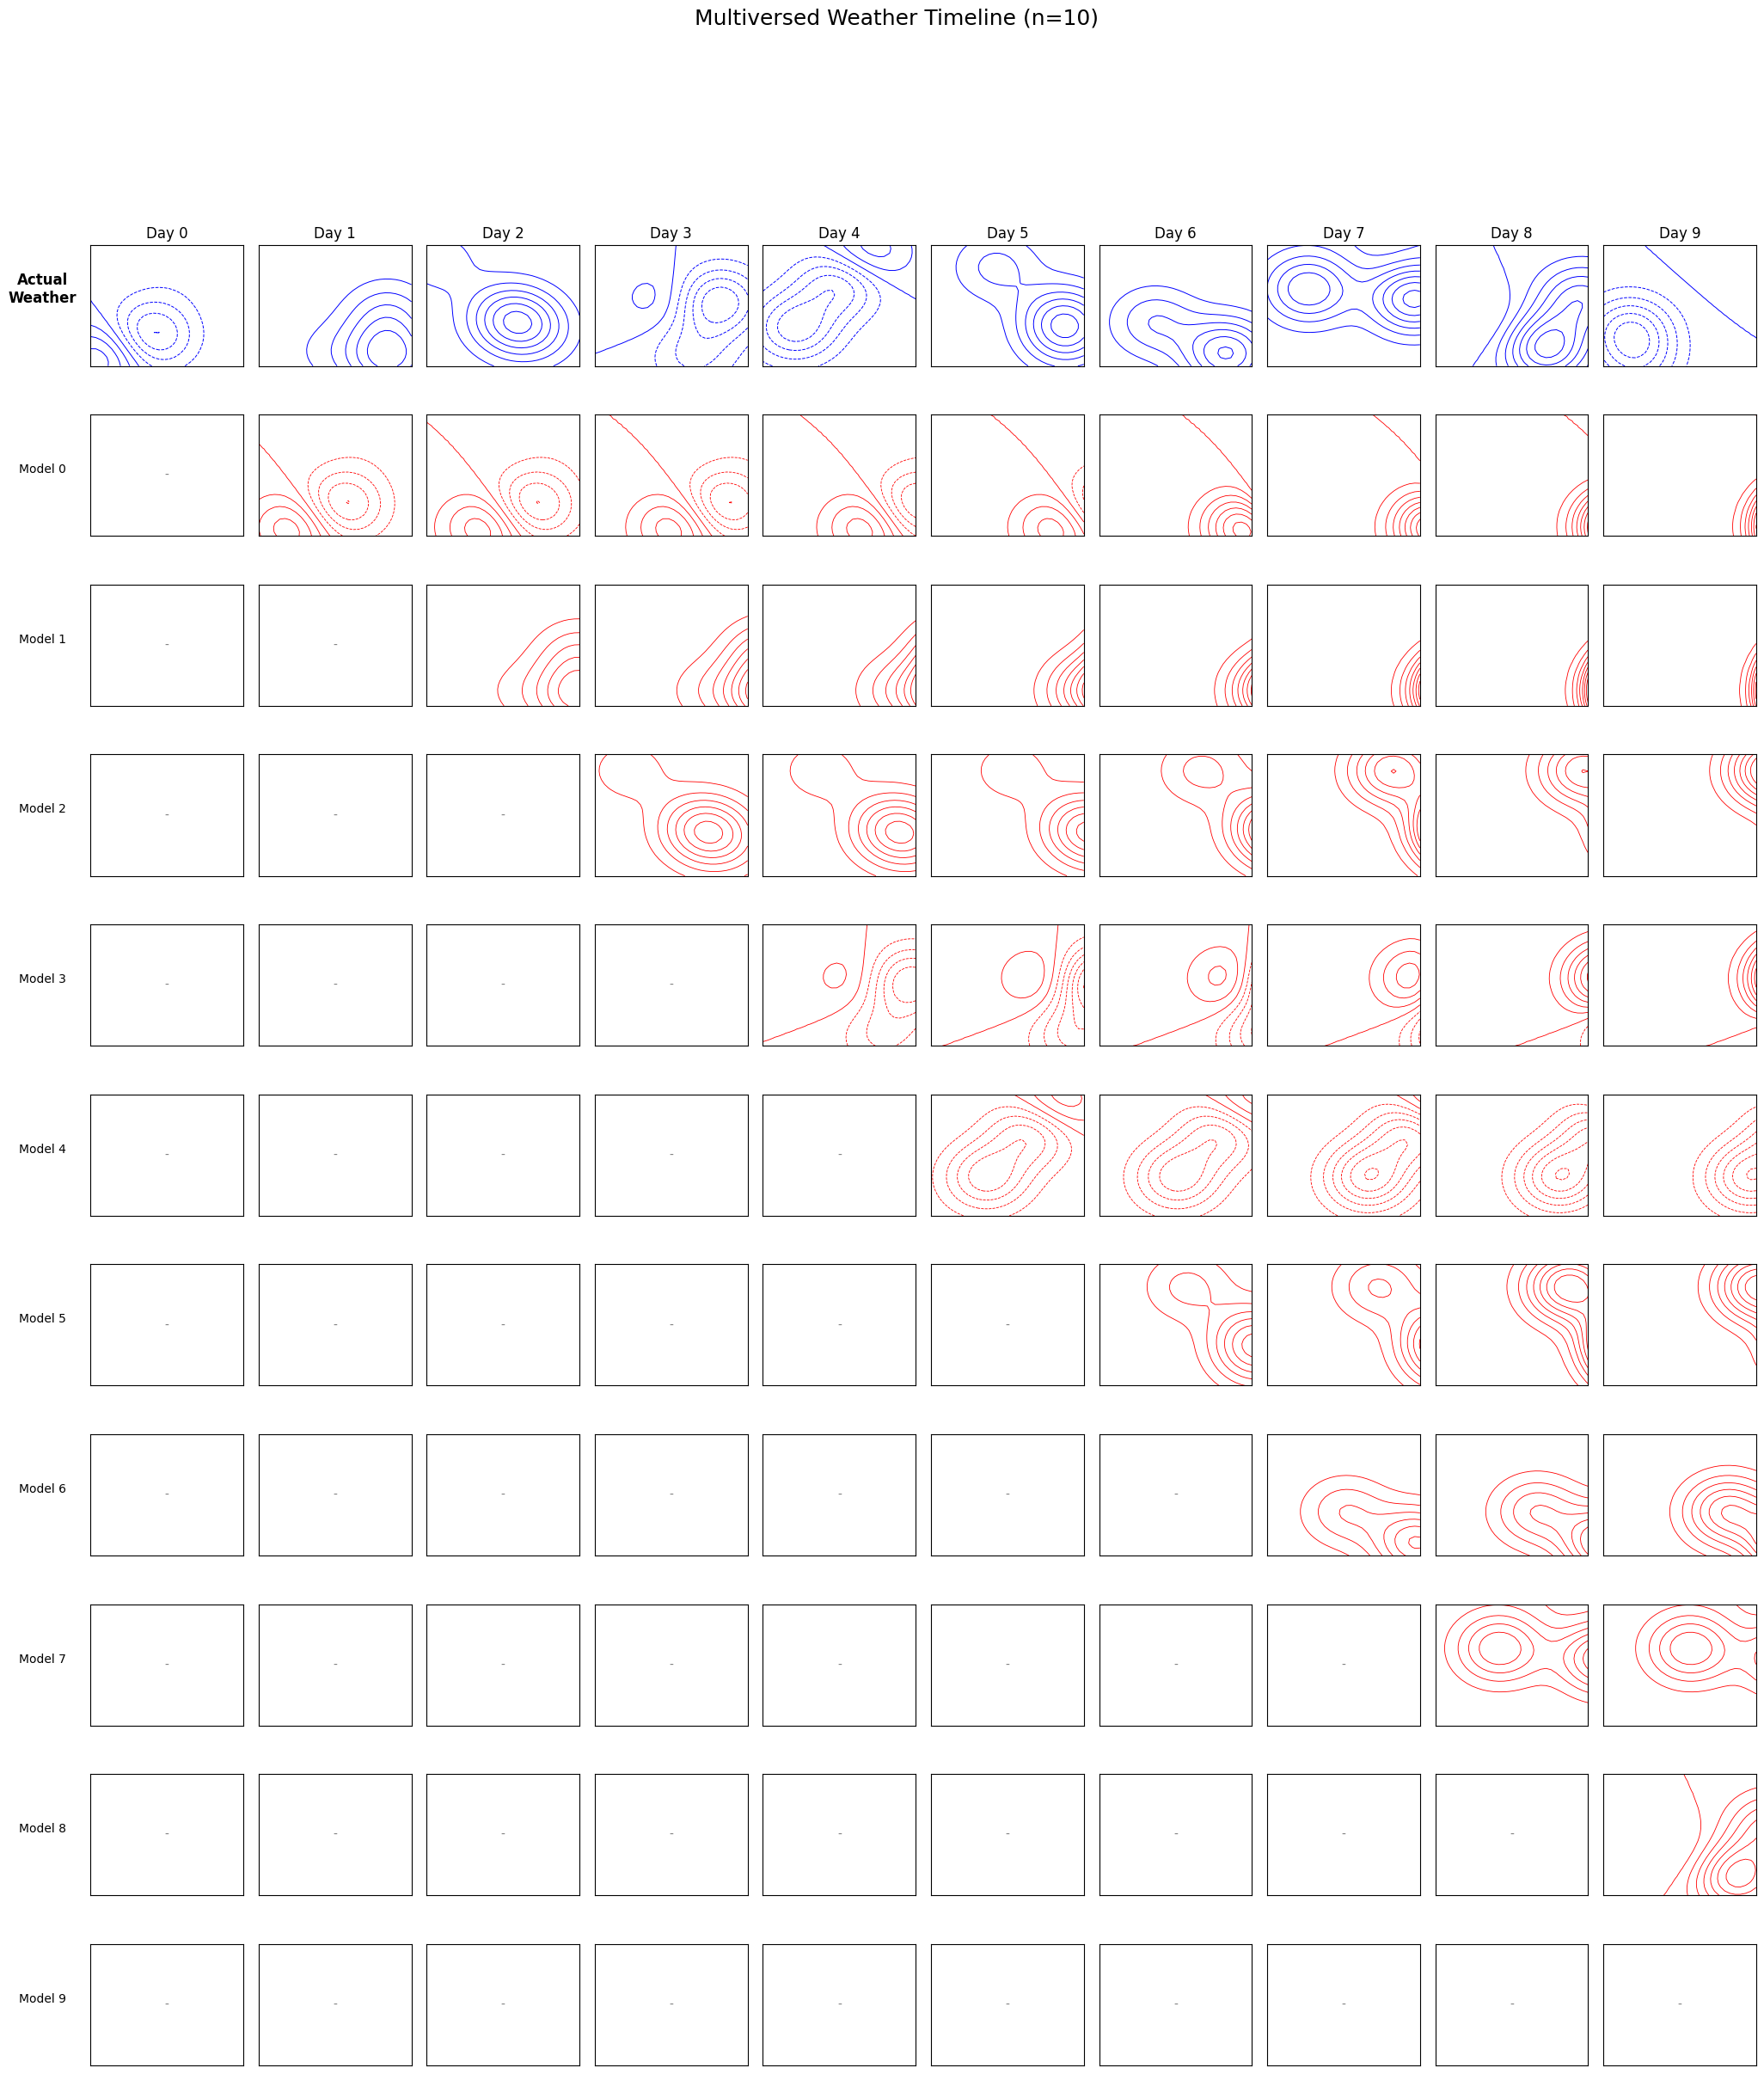

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def create_horizontal_multiverse(n=5):
    grid_size = 30
    x = np.linspace(0, 10, grid_size)
    y = np.linspace(0, 10, grid_size)
    X, Y = np.meshgrid(x, y)

    # 現実の天気のシード値を生成
    actual_seeds = [np.random.randint(0, 1000) for _ in range(n)]

    # 行：Weather + Model 0 ~ n-1 (合計 n+1 行)
    # 列：Day 0 ~ n-1 (合計 n 列)
    fig, axes = plt.subplots(n + 1, n, figsize=(n * 2.5, (n + 1) * 2.5))
    plt.subplots_adjust(wspace=0.1, hspace=0.4)

    def generate_z(seed, drift=0):
        np.random.seed(seed)
        Z = np.zeros((grid_size, grid_size))
        for _ in range(3):
            cx, cy = np.random.uniform(0, 10, 2)
            strength = np.random.uniform(-1, 1)
            # 宇宙の膨張/乖離を表現
            Z += strength * np.exp(-((X - (cx + drift))**2 + (Y - cy)**2) / 8)
        return Z

    for d in range(n):
        # --- 行0: Weathers (現実の推移) ---
        ax_weather = axes[0, d]
        Z_act = generate_z(actual_seeds[d])
        ax_weather.contour(X, Y, Z_act, colors='blue', linewidths=0.7)
        if d == 0: ax_weather.set_ylabel("Actual\nWeather", fontsize=12, fontweight='bold', rotation=0, labelpad=40)
        ax_weather.set_title(f"Day {d}", fontsize=12)

        # --- 行1〜n: 各モデルの宇宙 ---
        for m_id in range(n):
            ax = axes[m_id + 1, d]
            if d == 0 and m_id >= 0: # 行ラベル
                axes[m_id + 1, 0].set_ylabel(f"Model {m_id}", fontsize=10, rotation=0, labelpad=40)

            if d <= m_id:
                # 誕生前（NaN）
                ax.text(0.5, 0.5, "-", ha='center', va='center', color='gray')
            else:
                # 誕生日の現実をシードにし、経過日数に応じて乖離
                drift_val = (d - m_id) * 1.5
                Z_pred = generate_z(actual_seeds[m_id], drift=drift_val)
                ax.contour(X, Y, Z_pred, colors='red', linewidths=0.6)

            ax.set_xticks([]); ax.set_yticks([])

        ax_weather.set_xticks([]); ax_weather.set_yticks([])

    plt.suptitle(f"Multiversed Weather Timeline (n={n})", fontsize=18, y=0.98)
    plt.show()

# nを大きくしても横に伸びていきます
create_horizontal_multiverse(n=10)
